In [27]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model, model_selection
# Relative path pointing to the file in the current working directory
file_path = "./Real_estate_valuation_data_set.xlsx"

# 1. Read the Excel file
df = pd.read_excel(file_path)

# 2. Separate into Target (y) and Features (X)
y = df['Y house price of unit area']
X = df.drop(columns=['Y house price of unit area', 'No'])

# 3. Verify
print(X.shape)
X = X.to_numpy()
y= y.to_numpy()
print(X[0])


(414, 6)
[2012.9166667   32.          84.87882     10.          24.98298
  121.54024  ]


In [28]:
X_train,X_test,y_train,y_test = model_selection.train_test_split(X,y,test_size=30,random_state=0)
print ('Training Set: %d rows\nTest Set: %d rows' % (X_train.shape[0], X_test.shape[0]))

Training Set: 384 rows
Test Set: 30 rows


In [31]:
model = linear_model.LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
np.set_printoptions(suppress=True)
print("Predicted Labels :", np.round(y_pred)[:10])
print("Actual labels:", y_test[:10])


Predicted Labels : [39. 13. 42. 13. 42. 40. 41. 33. 50. 46.]
Actual labels: [45.3 14.4 46.  15.6 50.2 38.1 48.5 41.4 51.6 40.1]


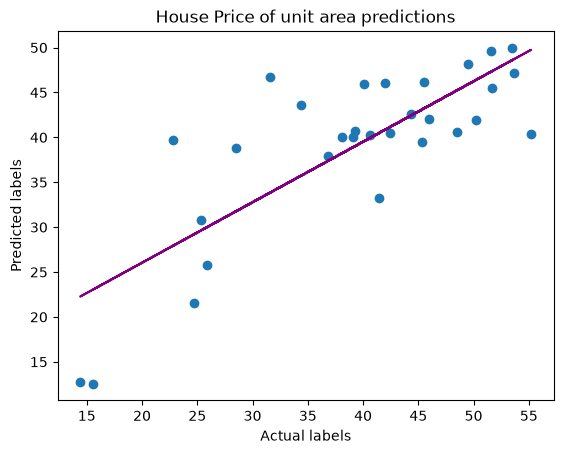

In [32]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual labels")
plt.ylabel("Predicted labels")
plt.title("House Price of unit area predictions")
z = np.polyfit(y_test,y_pred,1)
p = np.poly1d(z)
plt.plot(y_test,p(y_test),color="purple")
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
mse =mean_squared_error(y_test,y_pred)
print("MSE:",mse)
rmse = np.sqrt(mse)
print("RMSE:",rmse)
r2 = r2_score(y_test,y_pred)
print("R2:",r2)

MSE: 46.23032240555394
RMSE: 6.799288374937038
R2: 0.624411077164597
